In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

PALETTE = "husl"
BG      = "#ffffff"
FG      = "#000000"
GRID    = "#ffffff"
ACCENT  = "#1DB954"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": FG,
    "xtick.color": FG,     "ytick.color": FG,
    "text.color": FG,      "grid.color": GRID,
    "grid.linewidth": 0.5, "font.family": "DejaVu Sans",
    "axes.titlesize": 13,  "axes.titleweight": "bold",
})

In [24]:
df_raw = pd.read_csv('../data/spotify_tracks_raw.csv')
print(f"Shape  : {df_raw.shape}")
df_raw.head()

Shape  : (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [25]:
# exact duplicates
before = len(df_raw)
df = df_raw.drop_duplicates()
print(f"Exact-row dupes removed : {before - len(df):,}")

# same track_id across genres → keep highest popularity
dup_ids = df.duplicated(subset='track_id', keep=False).sum()
print(f"Rows sharing a track_id : {dup_ids:,}")
df = (
    df.sort_values('popularity', ascending=False)
      .drop_duplicates(subset='track_id', keep='first')
      .reset_index(drop=True)
)
print(f"After dedup by track_id : {len(df):,} rows")

Exact-row dupes removed : 0
Rows sharing a track_id : 40,900
After dedup by track_id : 89,741 rows


In [26]:
# missing values
missing = df.isnull().sum()
display(missing[missing > 0] if missing.any() else "No missing values")
df = df.dropna(subset=['track_name', 'artists', 'track_genre'])

artists       1
album_name    1
track_name    1
dtype: int64

In [27]:
# types & derived columns
df['explicit']     = df['explicit'].astype(bool)
df['duration_min'] = df['duration_ms'] / 60_000

KEY_MAP = {-1:'None',0:'C',1:'C♯',2:'D',3:'D♯',4:'E',
            5:'F',6:'F♯',7:'G',8:'G♯',9:'A',10:'A♯',11:'B'}
df['key_label']  = df['key'].map(KEY_MAP)
df['mode_label'] = df['mode'].map({0:'Minor', 1:'Major'})

print(f"Clean dataset : {df.shape}")
df.dtypes

Clean dataset : (89740, 24)


Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
duration_min        float64
key_label            object
mode_label           object
dtype: object

In [28]:
AUDIO = ['danceability','energy','loudness','speechiness',
         'acousticness','instrumentalness','liveness',
         'valence','tempo','duration_min','popularity']

desc = df[AUDIO].describe().T
desc['skew'] = df[AUDIO].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
danceability,89740.0,0.562166,0.176692,0.0000,0.45000,0.576000,0.692000,0.98500,-0.398292
energy,89740.0,0.634458,0.256606,0.0000,0.45700,0.676000,0.853000,1.00000,-0.559993
loudness,89740.0,-8.498994,5.221518,-49.5310,-10.32225,-7.185000,-5.108000,4.53200,-1.959879
speechiness,89740.0,0.087442,0.113278,0.0000,0.03600,0.048900,0.085900,0.96500,4.545835
acousticness,89740.0,0.328285,0.338321,0.0000,0.01710,0.188000,0.625000,0.99600,0.655772
instrumentalness,89740.0,0.173415,0.323849,0.0000,0.00000,0.000058,0.097625,1.00000,1.563997
liveness,89740.0,0.216971,0.194885,0.0000,0.09820,0.132000,0.279000,1.00000,2.062092
valence,89740.0,0.469474,0.262864,0.0000,0.24900,0.457000,0.682000,0.99500,0.127637
tempo,89740.0,122.058134,30.117651,0.0000,99.26275,122.013000,140.077000,243.37200,0.182744
duration_min,89740.0,3.819073,1.882430,0.1431,2.88400,3.554925,4.404883,87.28825,11.072801


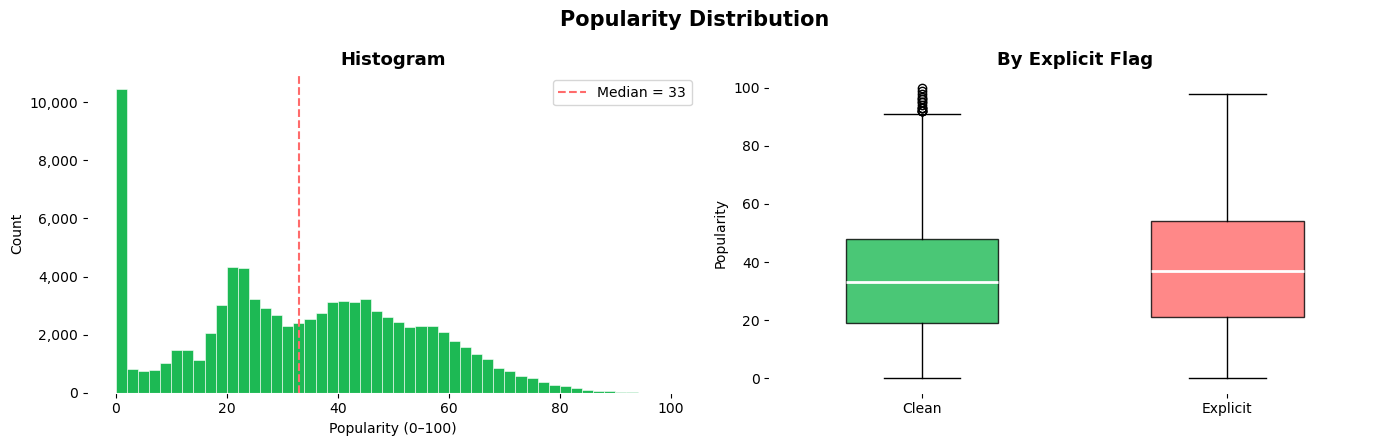

In [29]:
# 4a. Popularity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Popularity Distribution', fontsize=15, fontweight='bold')

ax = axes[0]
ax.hist(df['popularity'], bins=50, color=ACCENT, edgecolor=BG, linewidth=0.4)
ax.axvline(df['popularity'].median(), color='#ff6b6b', linewidth=1.5,
           linestyle='--', label=f"Median = {df['popularity'].median():.0f}")
ax.legend(); ax.set_xlabel('Popularity (0–100)'); ax.set_ylabel('Count')
ax.set_title('Histogram')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
groups = [df.loc[df['explicit'] == v, 'popularity'] for v in [False, True]]
bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [ACCENT, '#ff6b6b']):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(['Clean', 'Explicit'])
ax.set_title('By Explicit Flag'); ax.set_ylabel('Popularity')

plt.tight_layout(); plt.show()

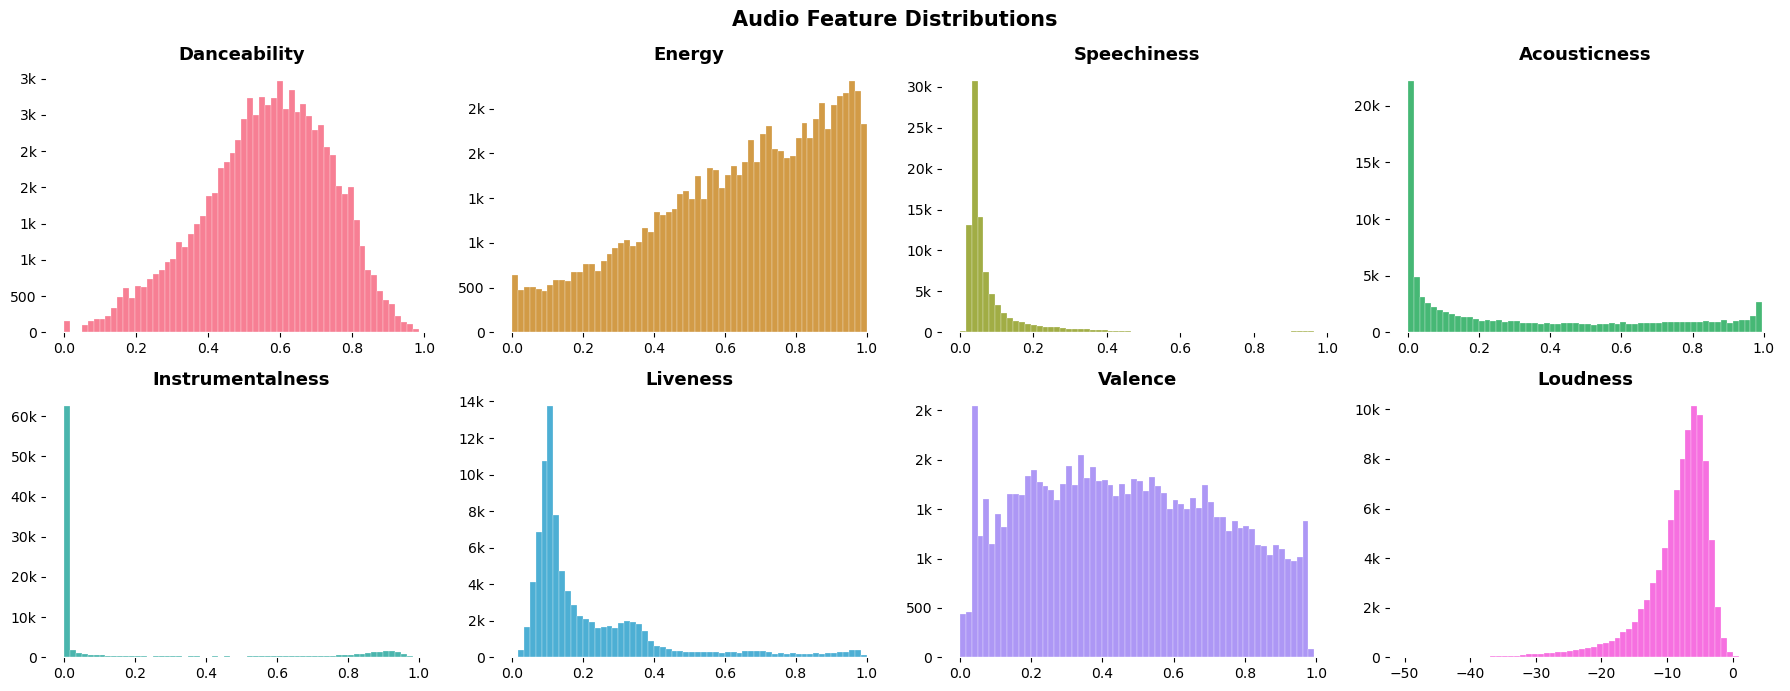

In [30]:
# 4b. Audio feature distributions
FEAT8 = ['danceability','energy','speechiness','acousticness',
         'instrumentalness','liveness','valence','loudness']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Audio Feature Distributions', fontsize=15, fontweight='bold')
palette = sns.color_palette(PALETTE, len(FEAT8))

for ax, feat, color in zip(axes.flat, FEAT8, palette):
    ax.hist(df[feat], bins=60, color=color, edgecolor=BG, linewidth=0.2, alpha=0.9)
    ax.set_title(feat.capitalize())
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x))))

plt.tight_layout(); plt.show()

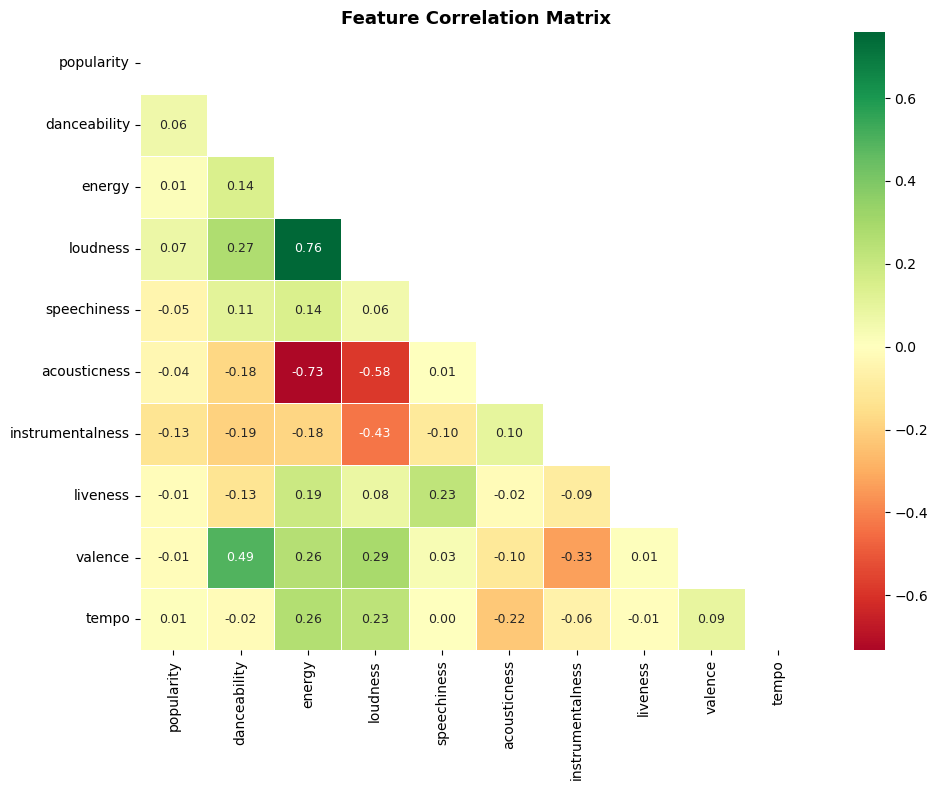

In [31]:
# 4c. Correlation heatmap
corr_cols = ['popularity','danceability','energy','loudness','speechiness',
             'acousticness','instrumentalness','liveness','valence','tempo']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor=BG, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()

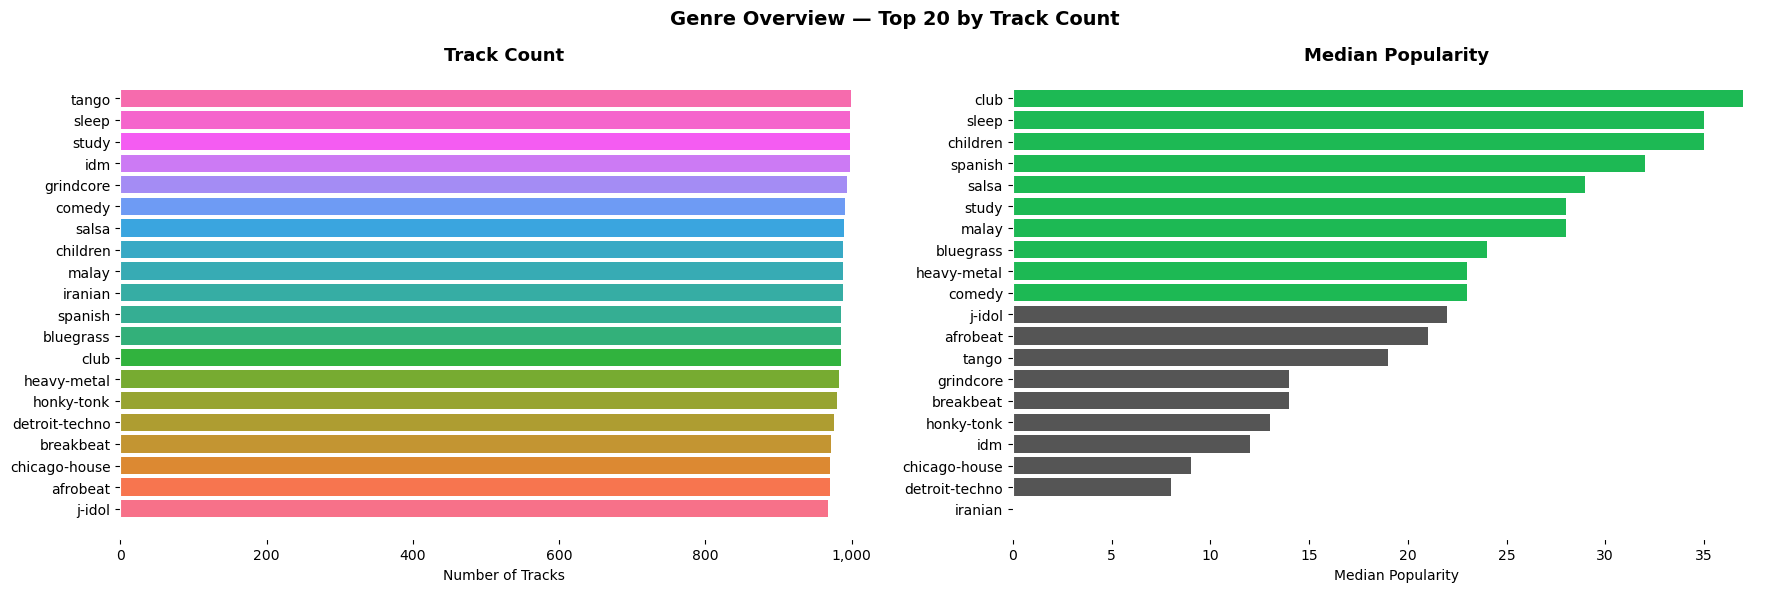

In [32]:
# 4d. Top 20 genres
genre_stats = (
    df.groupby('track_genre')
      .agg(count=('track_id','count'), median_pop=('popularity','median'))
      .sort_values('count', ascending=False)
)
top20 = genre_stats.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Genre Overview — Top 20 by Track Count', fontsize=14, fontweight='bold')

ax = axes[0]
ax.barh(top20.index[::-1], top20['count'][::-1],
        color=sns.color_palette(PALETTE, 20))
ax.set_xlabel('Number of Tracks'); ax.set_title('Track Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
pop_sorted = top20.sort_values('median_pop', ascending=False)
med = pop_sorted['median_pop'].median()
colors = [ACCENT if v >= med else '#555' for v in pop_sorted['median_pop']]
ax.barh(pop_sorted.index[::-1], pop_sorted['median_pop'][::-1], color=colors[::-1])
ax.set_xlabel('Median Popularity'); ax.set_title('Median Popularity')

plt.tight_layout(); plt.show()

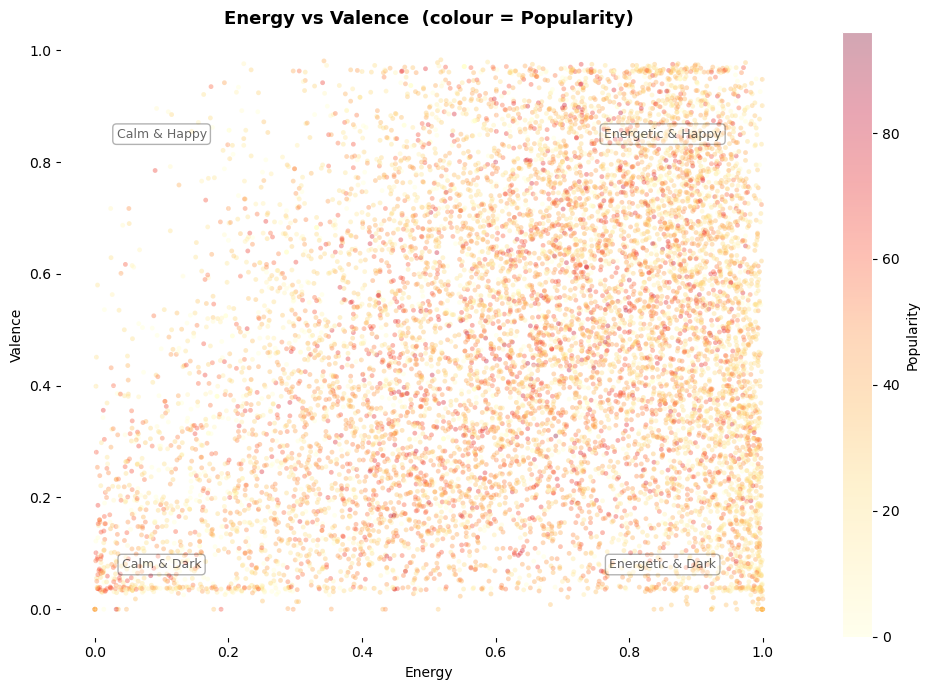

In [33]:
# 4e. Energy vs Valence scatter
sample = df.sample(min(10_000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sample['energy'], sample['valence'],
                c=sample['popularity'], cmap='YlOrRd',
                alpha=0.35, s=12, linewidths=0)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Popularity', color=FG)
cbar.ax.yaxis.set_tick_params(color=FG)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=FG)

ax.set_xlabel('Energy'); ax.set_ylabel('Valence')
ax.set_title('Energy vs Valence  (colour = Popularity)')
ax.grid(True, alpha=0.2)

for x, y, label in [
    (0.1,  0.85, 'Calm & Happy'),
    (0.85, 0.85, 'Energetic & Happy'),
    (0.1,  0.08, 'Calm & Dark'),
    (0.85, 0.08, 'Energetic & Dark'),
]:
    ax.text(x, y, label, fontsize=9, color=FG, alpha=0.6,
            ha='center', va='center',
            bbox=dict(facecolor=BG, alpha=0.3, boxstyle='round'))

plt.tight_layout(); plt.show()

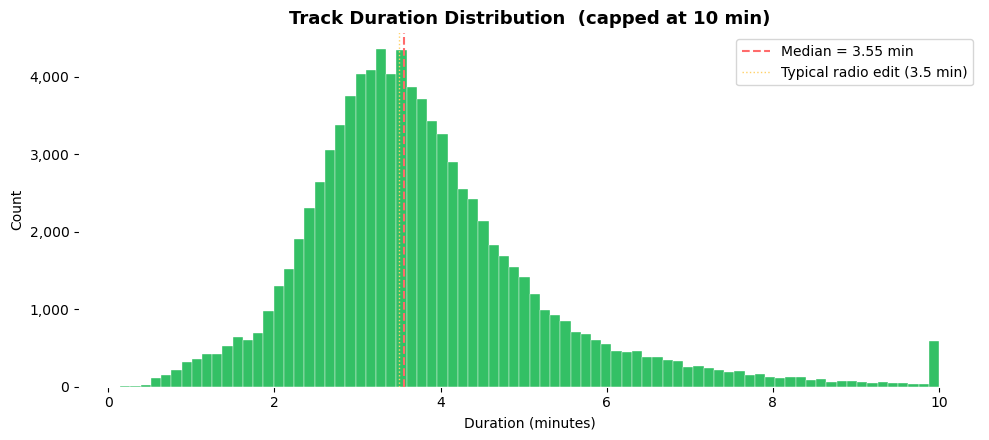

In [34]:
# 4f. Duration distribution
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(df['duration_min'].clip(upper=10), bins=80,
        color=ACCENT, edgecolor=BG, linewidth=0.3, alpha=0.9)
ax.axvline(df['duration_min'].median(), color='#ff6b6b', linewidth=1.5,
           linestyle='--', label=f"Median = {df['duration_min'].median():.2f} min")
ax.axvline(3.5, color='#ffd166', linewidth=1, linestyle=':',
           label='Typical radio edit (3.5 min)')
ax.set_xlabel('Duration (minutes)'); ax.set_ylabel('Count')
ax.set_title('Track Duration Distribution  (capped at 10 min)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()

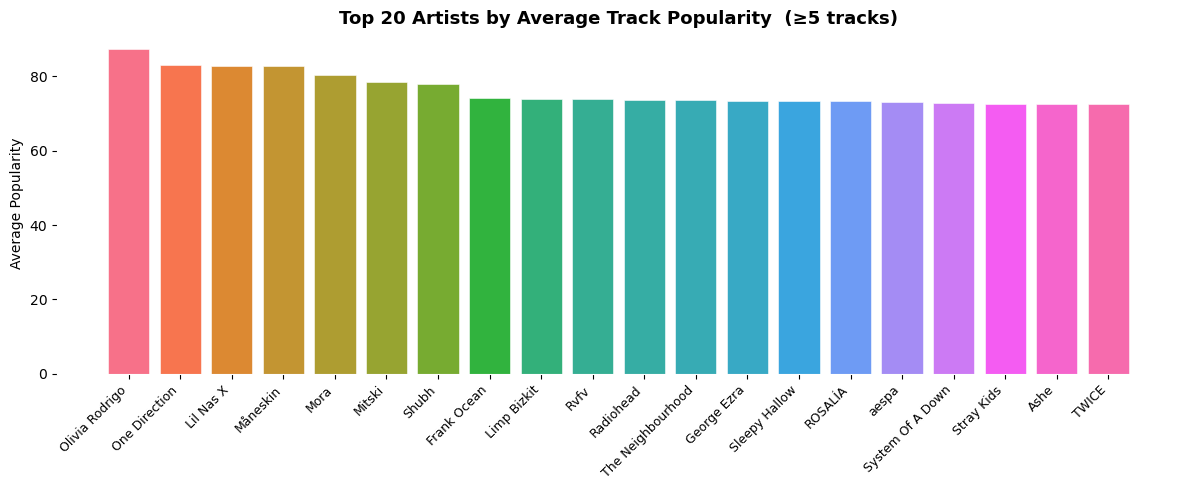

In [35]:
# 4g. Top 20 artists by avg popularity (≥5 tracks)
artists_exp = (
    df.assign(artist=df['artists'].str.split(';'))
      .explode('artist')
)
artists_exp['artist'] = artists_exp['artist'].str.strip()

top_artists = (
    artists_exp.groupby('artist')
      .agg(track_count=('track_id','nunique'), avg_pop=('popularity','mean'))
      .query('track_count >= 5')
      .sort_values('avg_pop', ascending=False)
      .head(20)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top_artists)), top_artists['avg_pop'],
       color=sns.color_palette(PALETTE, len(top_artists)),
       edgecolor=BG, linewidth=0.4)
ax.set_xticks(range(len(top_artists)))
ax.set_xticklabels(top_artists.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Average Popularity')
ax.set_title('Top 20 Artists by Average Track Popularity  (≥5 tracks)')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

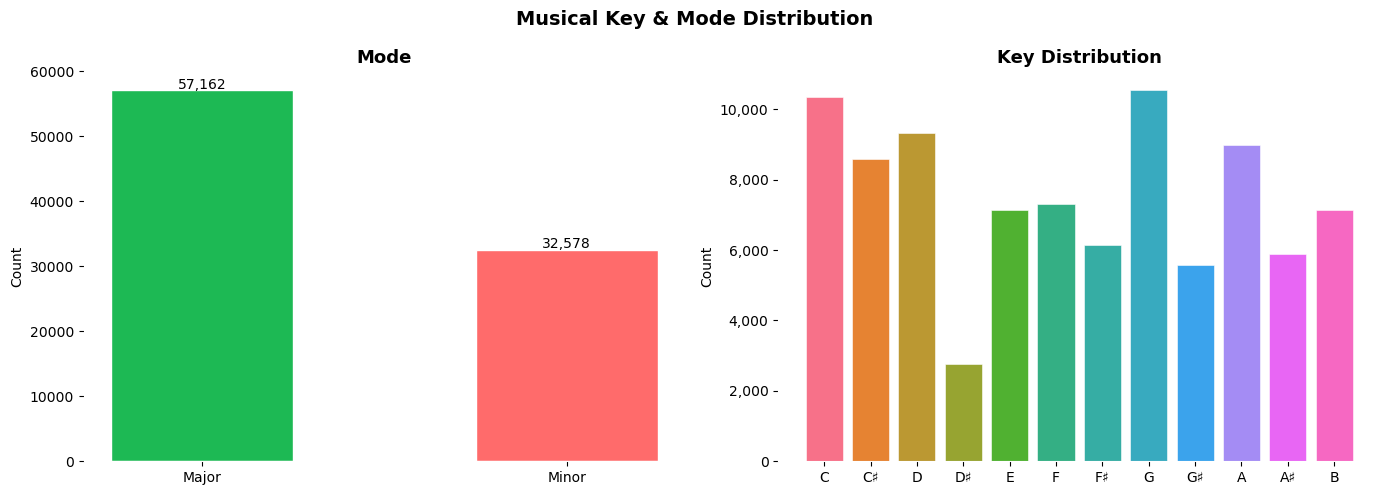

In [36]:
# 4h. Key & Mode distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Musical Key & Mode Distribution', fontsize=14, fontweight='bold')

ax = axes[0]
mode_counts = df['mode_label'].value_counts()
ax.bar(mode_counts.index, mode_counts.values,
       color=[ACCENT, '#ff6b6b'], edgecolor=BG, width=0.5)
ax.set_title('Mode'); ax.set_ylabel('Count')
for i, v in enumerate(mode_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha='center', fontsize=10)

ax = axes[1]
key_order = ['C','C♯','D','D♯','E','F','F♯','G','G♯','A','A♯','B']
key_counts = df['key_label'].value_counts().reindex(key_order, fill_value=0)
ax.bar(key_counts.index, key_counts.values,
       color=sns.color_palette('husl', len(key_order)),
       edgecolor=BG, linewidth=0.4)
ax.set_title('Key Distribution'); ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout(); plt.show()

In [37]:
df.to_csv('../data/spotify_tracks_clean.csv', index=False)

print(f"Saved  → ../data/spotify_tracks_clean.csv")
print(f"Raw    : {len(df_raw):,} rows")
print(f"Clean  : {len(df):,} rows")
print(f"Removed: {len(df_raw) - len(df):,}  ({(1 - len(df)/len(df_raw))*100:.1f}%)")

Saved  → ../data/spotify_tracks_clean.csv
Raw    : 114,000 rows
Clean  : 89,740 rows
Removed: 24,260  (21.3%)
